# 04 — Retrain Pipeline

Interactive walk-through of the drift-detection and retraining logic that runs daily in GitHub Actions (`src/training/retrain.py`).

---

## How retraining works in production

### The runner is ephemeral

Every day at **06:00 UTC**, GitHub Actions spins up a fresh Ubuntu runner, clones the repository, installs dependencies, and executes `retrain.py`. The runner has no memory of previous runs — it starts from a clean slate every time.

This means the runner itself **never stores the model**. Instead:

1. The current model artifacts (`rf_model.save`, `scaler_X.pkl`, `scaler_y.pkl`) are committed to the repository so GHA can clone them.
2. After a successful retrain the updated artifacts are committed back to `main` via `git push`, making them available to the next run.

### What happens when retraining is triggered

```
GitHub Actions runner (ephemeral, x86 Ubuntu)
│
├─ 1. git clone → gets latest model from repo
├─ 2. python retrain.py
│       ├─ download fresh BTC-USD history (yfinance)
│       ├─ drift check: recent MAE vs 1.5 × baseline RMSE
│       └─ if drift (or --force):
│               ├─ train new RandomForest on full history
│               ├─ overwrite rf_model.save / scaler_*.pkl
│               └─ build new Docker image with updated model baked in
│                       └─ docker push → Docker Hub (brunopulheze/btc-predictor:latest)
│
└─ 3. OCI VM (always-on, ARM)
        ├─ docker pull brunopulheze/btc-predictor:latest
        ├─ docker stop btc-predictor && docker rm btc-predictor
        └─ docker run ... → new container now serves the retrained model
```

The model is **baked into the Docker image** at build time (`COPY models/ /app/models/`). The OCI VM never trains anything — it only runs the pre-built image.

When drift is **not** detected, retraining and image rebuild are skipped. The runner still copies a fresh `drift_report.json` into the running container so the dashboard always shows up-to-date evaluation metrics.

### Why retraining runs on GHA and not on the OCI VM

| Concern | GitHub Actions runner | OCI VM (Always Free) |
|---------|----------------------|----------------------|
| **CPU** | 2-core x86, no time limit per job | 4-core ARM, but shared with the live API |
| **RAM** | 7 GB | 6 GB total — Flask + gunicorn already running |
| **Cost** | Free (2 000 min/month included) | Free — but retraining would starve the API |
| **Isolation** | Ephemeral — failure can't corrupt the live service | Retraining crash = API crash |
| **Secrets** | `GITHUB_TOKEN`, Docker Hub credentials managed by GHA | Would need to manage secrets on the VM |
| **Rollback** | Bad model = just revert the git commit | Bad model = manual SSH + docker pull |

GHA gives us a **clean, isolated environment for every run** at zero extra cost, while the OCI VM stays focused on serving predictions without interruption.

---

## Steps covered in this notebook

| # | Step | Outcome |
|---|------|---------|
| 1 | Imports & config | shared constants |
| 2 | Feature engineering helpers | `_rsi`, `_macd`, `build_features` |
| 3 | Download BTC-USD history | raw price DataFrame |
| 4 | Build feature matrix | ready-to-model DataFrame |
| 5 | Load existing model | RF + scalers from `models/` |
| 6 | Drift detection | recent MAE vs threshold |
| 7 | Visualise predictions vs actuals | drift plot |
| 8 | Retrain | new RF trained on full history |
| 9 | Evaluate new model | RMSE comparison |
| 10 | Save artifacts | overwrite `models/` files |
| 11 | Write `drift_report.json` | consumed by dashboard |

> **Tip:** Run all cells top to bottom. To force a retrain regardless of drift, set `FORCE_RETRAIN = True` in Cell 1.

## 1 — Imports & Configuration

In [1]:
from __future__ import annotations

import datetime
import json
import os
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler

try:
    import mlflow
    _MLFLOW = True
except ImportError:
    _MLFLOW = False

# ── Paths (works whether run from notebooks/ or project root) ──────────
_REPO      = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
MODEL_DIR  = os.path.join(_REPO, "models")
sys.path.insert(0, os.path.join(_REPO, "src"))

# ── Hyper-parameters (mirror src/training/retrain.py) ─────────────────
SEQ_LEN         = 20    # number of lag features
EVAL_DAYS       = 30    # recent window for drift detection
DRIFT_THRESHOLD = 1.5   # retrain if recent_MAE > threshold × baseline_RMSE
FORCE_RETRAIN   = False # set True to skip drift check and always retrain

print(f"MODEL_DIR : {MODEL_DIR}")
print(f"MLflow    : {'available' if _MLFLOW else 'not installed (will skip logging)'}")

MODEL_DIR : c:\Users\User\Desktop\Ironhack-DS-AI\capstone-ml-on-cloud\models
MLflow    : available


## 2 — Feature Engineering

Three indicators are computed from raw closing prices and shifted by 1 day so prediction for day *t* only uses information known at day *t − 1*.

- **`return`** — percentage change: $(close_t - close_{t-1}) / close_{t-1}$
- **`std30`** — 30-day rolling volatility (standard deviation of close)
- **`rsi14`** — Relative Strength Index over 14 days (0–100 momentum oscillator)
- **`macd` / `macd_sig`** — MACD line (EMA12 − EMA26) and its 9-day signal
- **`lag_1 … lag_20`** — last 20 closing prices (raw price memory for the forest)

In [2]:
def _rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    up    = delta.clip(lower=0).rolling(period).mean()
    down  = -delta.clip(upper=0).rolling(period).mean()
    return 100 - (100 / (1 + up / down))


def _macd(series: pd.Series, a: int = 12, b: int = 26, c: int = 9):
    ema_a = series.ewm(span=a, adjust=False).mean()
    ema_b = series.ewm(span=b, adjust=False).mean()
    line  = ema_a - ema_b
    sig   = line.ewm(span=c, adjust=False).mean()
    return line, sig


def build_features(prices: list[float], seq_len: int = SEQ_LEN) -> pd.DataFrame:
    d = pd.DataFrame({"Close": prices})
    d["return"]   = d["Close"].pct_change().shift(1)
    d["std30"]    = d["Close"].rolling(30).std().shift(1)
    d["rsi14"]    = _rsi(d["Close"]).shift(1)
    ml, ms        = _macd(d["Close"])
    d["macd"]     = ml.shift(1)
    d["macd_sig"] = ms.shift(1)
    d = d.dropna().reset_index(drop=True)
    for i in range(1, seq_len + 1):
        d[f"lag_{i}"] = d["Close"].shift(i)
    return d.dropna().reset_index(drop=True)


def _feature_cols(seq_len: int = SEQ_LEN) -> list[str]:
    return [f"lag_{i}" for i in range(1, seq_len + 1)] + ["std30", "rsi14", "macd", "macd_sig", "return"]


print("Feature helpers defined.")

Feature helpers defined.


## 3 — Download BTC-USD History

4249 daily closes  (2014-09-17 → 2026-05-05)


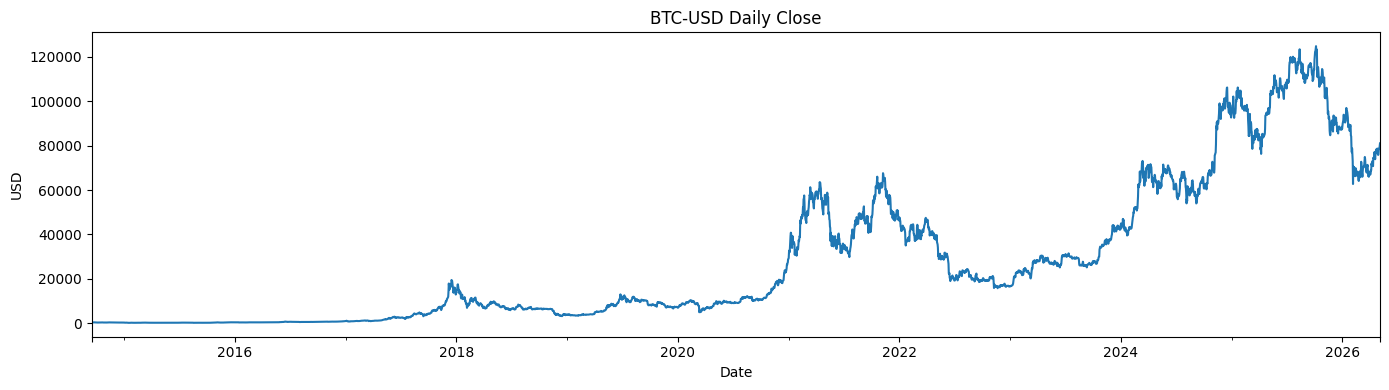

In [3]:
raw = yf.download("BTC-USD", start="2014-01-01", progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

prices = raw["Close"].dropna().squeeze().tolist()
print(f"{len(prices)} daily closes  ({raw.index[0].date()} → {raw.index[-1].date()})")

raw["Close"].plot(figsize=(14, 4), title="BTC-USD Daily Close", ylabel="USD")
plt.tight_layout()
plt.show()

## 4 — Build Feature Matrix

In [4]:
feat_df = build_features(prices, SEQ_LEN)
print(f"Feature matrix: {feat_df.shape[0]} rows × {feat_df.shape[1]} columns")
feat_df.tail()

Feature matrix: 4199 rows × 26 columns


,Close,return,std30,rsi14,macd,macd_sig,lag_1,lag_2,lag_3,lag_4,...,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20
4194,78179.000000,0.006970,3677.188013,53.819407,1514.686994,1760.117722,76304.320312,75776.132812,76350.671875,77366.625000,...,75872.523438,73856.351562,75726.210938,77126.875000,75152.132812,74805.078125,74181.609375,74484.640625,70753.406250,73054.273438
4195,78657.250000,0.024568,3602.587425,53.511000,1542.835169,1716.661212,78179.000000,76304.320312,75776.132812,76350.671875,...,76352.773438,75872.523438,73856.351562,75726.210938,77126.875000,75152.132812,74805.078125,74181.609375,74484.640625,70753.406250
4196,78538.226562,0.006117,3429.460870,60.422694,1585.457412,1690.420452,78657.250000,78179.000000,76304.320312,75776.132812,...,78203.101562,76352.773438,75872.523438,73856.351562,75726.210938,77126.875000,75152.132812,74805.078125,74181.609375,74484.640625
4197,79827.906250,-0.001513,3196.559932,69.016527,1591.288270,1670.594015,78538.226562,78657.250000,78179.000000,76304.320312,...,78268.953125,78203.101562,76352.773438,75872.523438,73856.351562,75726.210938,77126.875000,75152.132812,74805.078125,74181.609375
4198,81007.218750,0.016421,2985.985239,67.073315,1680.602698,1672.595752,79827.906250,78538.226562,78657.250000,78179.000000,...,77455.312500,78268.953125,78203.101562,76352.773438,75872.523438,73856.351562,75726.210938,77126.875000,75152.132812,74805.078125


## 5 — Load Existing Model

Loads the production artifacts from `models/`. If they don't exist (cold start), we skip directly to retraining.

In [5]:
model_path    = os.path.join(MODEL_DIR, "rf_model.save")
scaler_x_path = os.path.join(MODEL_DIR, "scaler_X.pkl")
scaler_y_path = os.path.join(MODEL_DIR, "scaler_y.pkl")
selection_path = os.path.join(MODEL_DIR, "selection.json")

cold_start = not os.path.exists(model_path)

if cold_start:
    print("No rf_model.save found — cold start. Will train from scratch.")
    model = scaler_X = scaler_y = None
    sel = {}
else:
    model    = joblib.load(model_path)
    scaler_X = joblib.load(scaler_x_path)
    scaler_y = joblib.load(scaler_y_path)
    sel      = json.load(open(selection_path)) if os.path.exists(selection_path) else {}
    print(f"Loaded model:    {model_path}")
    print(f"n_estimators:    {model.n_estimators}")
    print(f"selection.json:  {sel}")

Loaded model:    c:\Users\User\Desktop\Ironhack-DS-AI\capstone-ml-on-cloud\models\rf_model.save
n_estimators:    300
selection.json:  {'model_type': 'rf', 'model_path': 'c:\\Users\\User\\Desktop\\Ironhack-DS-AI\\capstone-ml-on-cloud\\models\\rf_model.save', 'logret_rmse': 0.02821, 'rmse': 1910.71, 'persistence_rmse': 1716.76, 'features': ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'std30', 'rsi14', 'macd', 'macd_sig', 'return'], 'n_estimators': 300, 'retrained': '2026-05-04T06:54:04.861870'}


## 6 — Drift Detection

Run the current model on the last `EVAL_DAYS` days and measure the Mean Absolute Error (MAE) in USD.

**Trigger condition:** `recent_MAE > DRIFT_THRESHOLD × baseline_RMSE`

- `DRIFT_THRESHOLD = 1.5` — 50% above baseline before we retrain
- If drift is detected (or `FORCE_RETRAIN = True`), execution continues to Step 8

In [6]:
baseline_rmse = float(sel.get("rmse", 1901.0))
threshold     = DRIFT_THRESHOLD * baseline_rmse
recent_mae: float | None = None
drift = False

if cold_start:
    print("Cold start — skipping drift detection.")
    drift = True
else:
    fcols      = _feature_cols(SEQ_LEN)
    eval_rows  = feat_df.iloc[-EVAL_DAYS:]
    actual     = eval_rows["Close"].values

    X_eval   = eval_rows[fcols].values
    X_eval_s = scaler_X.transform(X_eval)

    scaled_preds = model.predict(X_eval_s).ravel()
    log_rets     = scaler_y.inverse_transform(scaled_preds.reshape(-1, 1)).ravel()
    prev_closes  = eval_rows["lag_1"].values
    predictions  = prev_closes * np.exp(log_rets)

    recent_mae = float(mean_absolute_error(actual, predictions))
    drift      = recent_mae > threshold

    print(f"Baseline RMSE  : ${baseline_rmse:>10,.2f}")
    print(f"Drift threshold: ${threshold:>10,.2f}  ({DRIFT_THRESHOLD}× baseline)")
    print(f"Recent MAE     : ${recent_mae:>10,.2f}  (last {EVAL_DAYS} days)")
    print(f"Drift detected : {drift}")
    if drift:
        print("\n→ Retraining will be triggered.")
    else:
        print("\n→ Model is healthy. No retraining needed (unless FORCE_RETRAIN=True).")

Baseline RMSE  : $  1,910.71
Drift threshold: $  2,866.07  (1.5× baseline)
Recent MAE     : $  1,433.36  (last 30 days)
Drift detected : False

→ Model is healthy. No retraining needed (unless FORCE_RETRAIN=True).


## 7 — Visualise: Predictions vs Actuals (last 30 days)

Only runs when a model was loaded (not on cold start).

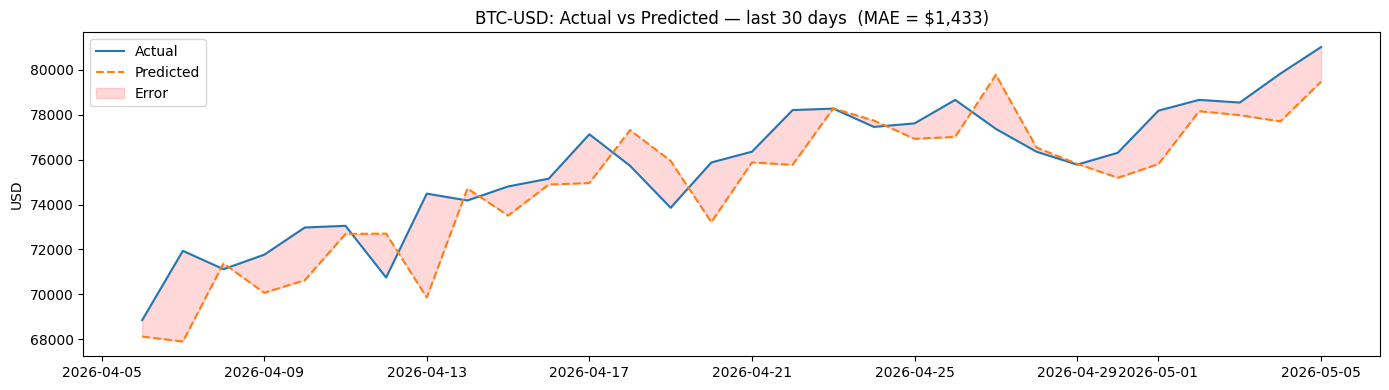

In [7]:
if not cold_start:
    dates = raw.index[-EVAL_DAYS:]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(dates, actual,      label="Actual",     linewidth=1.5)
    ax.plot(dates, predictions, label="Predicted",  linewidth=1.5, linestyle="--")
    ax.fill_between(dates, actual, predictions, alpha=0.15, color="red", label="Error")
    ax.set_title(f"BTC-USD: Actual vs Predicted — last {EVAL_DAYS} days  (MAE = ${recent_mae:,.0f})")
    ax.set_ylabel("USD")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No model loaded — skipping plot.")

## 8 — Retrain

Trains a new `RandomForestRegressor(n_estimators=300)` on the full price history using a **chronological 70/30 split** (no shuffling — avoids data leakage).

- Target: $\log(close_t / close_{t-1})$ (log-return)
- `scaler_X` (MinMaxScaler) fitted on training features only
- `scaler_y` (StandardScaler) fitted on training targets only

This cell runs only when drift is detected **or** `FORCE_RETRAIN = True`.

In [8]:
new_model = new_scaler_X = new_scaler_y = None
new_rmse = new_logret_rmse = None

if drift or FORCE_RETRAIN:
    reason = "forced" if FORCE_RETRAIN else "drift detected"
    print(f"Retraining ({reason})…")

    fcols  = _feature_cols(SEQ_LEN)
    X      = feat_df[fcols].values
    y      = np.log(feat_df["Close"].values / feat_df["lag_1"].values)

    split      = int(0.7 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    new_scaler_X  = MinMaxScaler()
    X_train_s     = new_scaler_X.fit_transform(X_train)
    X_test_s      = new_scaler_X.transform(X_test)

    new_scaler_y  = StandardScaler()
    y_train_s     = new_scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

    new_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    new_model.fit(X_train_s, y_train_s)
    print("Training complete.")
else:
    print("No retrain needed. Skipping (set FORCE_RETRAIN=True to override).")

No retrain needed. Skipping (set FORCE_RETRAIN=True to override).


## 9 — Evaluate New Model

Two metrics are computed:

| Metric | What it measures | Used for |
|--------|-----------------|----------|
| **Price RMSE** | Average USD error on the test set | Drift threshold in `drift_report.json` |
| **Log-return RMSE** | Model's directional accuracy | Honest skill metric in `selection.json` |

In [9]:
if new_model is not None:
    fcols  = _feature_cols(SEQ_LEN)
    X      = feat_df[fcols].values
    y      = np.log(feat_df["Close"].values / feat_df["lag_1"].values)
    split  = int(0.7 * len(X))

    X_test_s     = new_scaler_X.transform(X[split:])
    scaled_preds = new_model.predict(X_test_s).ravel()
    log_rets     = new_scaler_y.inverse_transform(scaled_preds.reshape(-1, 1)).ravel()
    prev_closes  = feat_df["lag_1"].iloc[split:].values
    actual_test  = feat_df["Close"].iloc[split:].values
    predicted_test = prev_closes * np.exp(log_rets)

    new_rmse        = float(np.sqrt(np.mean((predicted_test - actual_test) ** 2)))
    new_logret_rmse = float(np.sqrt(np.mean((y[split:] - log_rets) ** 2)))

    print(f"Old baseline RMSE : ${baseline_rmse:>10,.2f}")
    print(f"New price RMSE    : ${new_rmse:>10,.2f}")
    print(f"New logret RMSE   : {new_logret_rmse:.5f}")

    # Plot: test set actuals vs new predictions
    test_dates = raw.index[-len(actual_test):]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(test_dates, actual_test,    label="Actual",    linewidth=1)
    ax.plot(test_dates, predicted_test, label="Predicted", linewidth=1, linestyle="--")
    ax.set_title(f"New model — test set  (Price RMSE = ${new_rmse:,.0f})")
    ax.set_ylabel("USD")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No retrain was performed — nothing to evaluate.")

No retrain was performed — nothing to evaluate.


## 10 — Save Artifacts

Overwrites `models/rf_model.save`, `models/scaler_X.pkl`, `models/scaler_y.pkl`, and `models/selection.json`.

> **Warning:** This will replace the production model files. Only run if you are happy with the evaluation results above.

In [10]:
if new_model is not None:
    joblib.dump(new_model,    os.path.join(MODEL_DIR, "rf_model.save"))
    joblib.dump(new_scaler_X, os.path.join(MODEL_DIR, "scaler_X.pkl"))
    joblib.dump(new_scaler_y, os.path.join(MODEL_DIR, "scaler_y.pkl"))

    sel["rmse"]        = round(new_rmse, 2)
    sel["logret_rmse"] = round(new_logret_rmse, 5)
    sel["retrained"]   = datetime.datetime.utcnow().isoformat()
    with open(os.path.join(MODEL_DIR, "selection.json"), "w") as f:
        json.dump(sel, f, indent=2)

    print("Artifacts saved:")
    print(f"  {os.path.join(MODEL_DIR, 'rf_model.save')}")
    print(f"  {os.path.join(MODEL_DIR, 'scaler_X.pkl')}")
    print(f"  {os.path.join(MODEL_DIR, 'scaler_y.pkl')}")
    print(f"  {os.path.join(MODEL_DIR, 'selection.json')}")
else:
    print("No new model to save.")

No new model to save.


## 11 — Write `drift_report.json`

Updates `models/drift_report.json` — this file is read by the FastAPI `/drift-report` endpoint and displayed on the dashboard.

In [11]:
report: dict = {
    "timestamp":       datetime.datetime.utcnow().isoformat(),
    "eval_days":       EVAL_DAYS,
    "recent_mae":      round(recent_mae, 2) if recent_mae is not None else None,
    "baseline_rmse":   round(baseline_rmse, 2),
    "drift_threshold": round(threshold, 2),
    "drift_detected":  drift,
    "retrained":       new_model is not None,
}
if new_model is not None:
    report["new_rmse"]          = round(new_rmse, 2)
    report["new_logret_rmse"]   = round(new_logret_rmse, 5)

report_path = os.path.join(MODEL_DIR, "drift_report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"Written → {report_path}")
print(json.dumps(report, indent=2))

Written → c:\Users\User\Desktop\Ironhack-DS-AI\capstone-ml-on-cloud\models\drift_report.json
{
  "timestamp": "2026-05-05T07:13:41.367709",
  "eval_days": 30,
  "recent_mae": 1433.36,
  "baseline_rmse": 1910.71,
  "drift_threshold": 2866.07,
  "drift_detected": false,
  "retrained": false
}


C:\Users\User\AppData\Local\Temp\ipykernel_7220\13773346.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp":       datetime.datetime.utcnow().isoformat(),
